<a href="https://colab.research.google.com/github/denverkim/ALGORITHM/blob/main/LAB9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 인접행렬

In [4]:
def createGraph(V, edges):
    mat = [[0 for _ in range(V)] for _ in range(V)]
    # Add each edge to the adjacency matrix
    for it in edges:
        u = it[0]
        v = it[1]
        mat[u][v] = 1

         # since the graph is undirected
        mat[v][u] = 1
    return mat

In [18]:
mat

[[0, 1, 1], [1, 0, 1], [1, 1, 0]]

In [17]:
V = 3

# List of edges (u, v)
edges = [[0, 1], [0, 2], [1, 2]]

# Build the graph using edges
mat = createGraph(V, edges)
print("Adjacency Matrix Representation:")

for i in range(V):
    for j in range(V):
        print(mat[i][j], end=" ")
    print()

Adjacency Matrix Representation:
0 1 1 
1 0 1 
1 1 0 


# 인접리스트

In [24]:
def createGraph(V, edges):
    adj = [[] for _ in range(V)]
    # Add each edge to the adjacency list
    for it in edges:
        u = it[0]
        v = it[1]
        adj[u].append(v)

         # since the graph is undirected
        adj[v].append(u)
    return adj

In [25]:
V = 3

# List of edges (u, v)
edges = [[0, 1], [0, 2], [1, 2]]

# Build the graph using edges
adj = createGraph(V, edges)

print("Adjacency List Representation:")
for i in range(V):
    # Print the vertex
    print(f"{i}:", end=" ")
    for j in adj[i]:
          # Print its adjacent
          print(j, end=" ")
    print()

Adjacency List Representation:
0: 1 2 
1: 0 2 
2: 0 1 


In [26]:
adj

[[1, 2], [0, 2], [0, 1]]

In [27]:
# 상관관계 분석
distance = [277.6, 259.5, 269.1, 267, 255.6, 272.9]
score = [69, 71, 70, 70, 71, 69]

In [29]:
import pandas as pd

golf = pd.DataFrame({'distance': distance,
              'score': score})
golf

,distance,score
0,277.6,69
1,259.5,71
2,269.1,70
3,267.0,70
4,255.6,71
5,272.9,69


In [31]:
import numpy as np
np.corrcoef(golf.distance, golf.score)

array([[ 1.        , -0.96307368],
       [-0.96307368,  1.        ]])

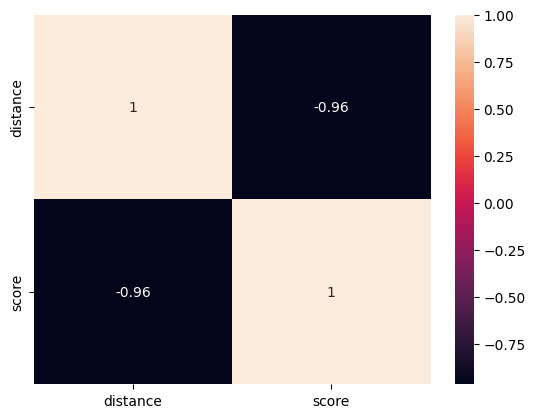

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(golf.corr(), annot=True)
plt.show()

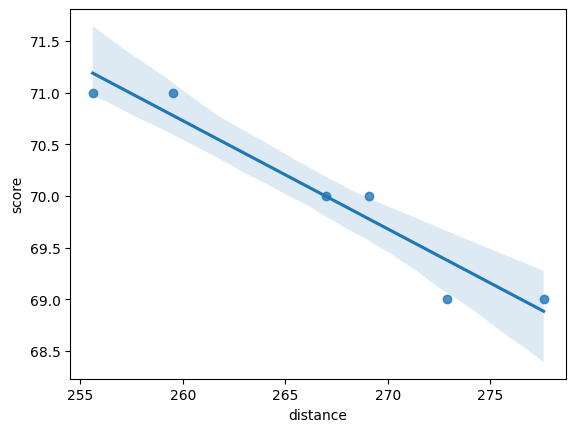

In [43]:
sns.regplot(x='distance', y='score', data=golf)
plt.show()

In [39]:
# 회귀분석
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(golf[['distance']], golf['score'])
print('기울기: ', model.coef_)
print('Y절편: ', model.intercept_)

기울기:  [-0.10480349]
Y절편:  97.97729257641917


In [42]:
import statsmodels.api as sm

model = sm.OLS(golf['score'], sm.add_constant(golf[['distance']])).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     51.18
Date:                Fri, 15 May 2026   Prob (F-statistic):            0.00202
Time:                        11:52:34   Log-Likelihood:                0.57572
No. Observations:                   6   AIC:                             2.849
Df Residuals:                       4   BIC:                             2.432
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.9773      3.912     25.044      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
